# Redes neuronales sobre imágenes

* Una imagen se puede representar como una matriz numérica de intensidades de color (RGB de 0 a 255 o GRAYS de 0 a 1) sobre cada pixel en cada columna y fila de la imagen.
* Para una red neuronal multicapa, cada observación será una imagen con su etiqueta del valor, por ejemplo, si la imagen contiene dígitos escritos a mano, entonces la etiqueta o respuesta será un número que corresponde al dígito, pero si la imagen contine un perro o un gato, entonces, la etiqueta será `perro` o `gato` y la respuesta será 0 o 1 si es perro o gato.
* Como en una red neuronal multicapa la entrada debe ser un vector, entonces deberemos representar la matriz numérica de cada imagen como un vector, por ejemplo, una imagen de 100x100 será un vector de tamaño 10,000 y una imagen de 28x28 será un vector de tamaño 784, entonces, la imagen de 100x100 tendrá 10,000 características numéricas, mientras que la imagen 28x28 tendrá 784 características, por lo que una imagen de 1024x768 pixeles, deberíamos reducirla a una imagen pobre de escasos 28x28 pixeles para que sea manejable
* Se requieren al menos miles de imágenes para que la red neuronal se pueda entrenar con 768 características, si tiene 10,000 características necesitaríamos cientos de miles o millones de imágenes, por eso, se reducen las imágenes aunque estén pixeleadas.

In [2]:
import numpy
import pandas
from matplotlib import pyplot
import seaborn
import keras

In [3]:
(X_train, Y_train), (X_test, Y_test) = keras.datasets.mnist.load_data()

X_train[0].shape, len(X_train), Y_train[0].shape, len(Y_train)

((28, 28), 60000, (), 60000)

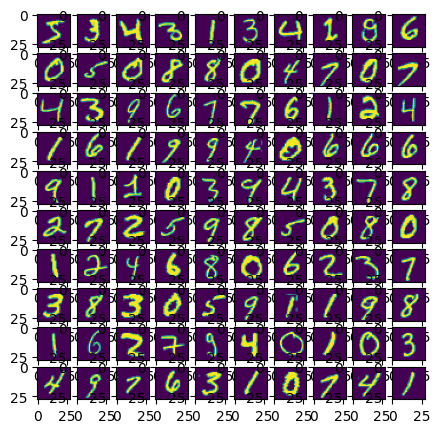

In [4]:
figure, axes = pyplot.subplots(10, 10, figsize=(5, 5))

for i in range(10):
    for j in range(10):
        axes[i][j].imshow(X_train[i + j * 10] / 255.0)
        # axes[i][j].text(1, 30, "A")
pyplot.show()

In [18]:
Xa = X_train.reshape(-1, 28 * 28) / 255

Xa[:10]

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [20]:
Xa.shape

(60000, 784)

In [22]:
Y_train[:10]

array([5, 0, 4, 1, 9, 2, 1, 3, 1, 4], dtype=uint8)

In [23]:
y0 = (Y_train == 0).astype(int)
y1 = (Y_train == 1).astype(int)
y2 = (Y_train == 2).astype(int)
y3 = (Y_train == 3).astype(int)
y4 = (Y_train == 4).astype(int)
y5 = (Y_train == 5).astype(int)
y6 = (Y_train == 6).astype(int)
y7 = (Y_train == 7).astype(int)
y8 = (Y_train == 8).astype(int)
y9 = (Y_train == 9).astype(int)

Ya = pandas.DataFrame([y0, y1, y2, y3, y4, y5, y6, y7, y8, y9]).T

Ya

,0,1,2,3,4,5,6,7,8,9
0,0,0,0,0,0,1,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0
2,0,0,0,0,1,0,0,0,0,0
3,0,1,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...
59995,0,0,0,0,0,0,0,0,1,0
59996,0,0,0,1,0,0,0,0,0,0
59997,0,0,0,0,0,1,0,0,0,0
59998,0,0,0,0,0,0,1,0,0,0


In [28]:
modelo = keras.Sequential([
    keras.Input(shape=(28 * 28,)),
    keras.layers.Dense(10, activation="sigmoid"),
])

modelo.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
modelo.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

Epoch 1/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 602us/step - accuracy: 0.8062 - loss: 0.7356
Epoch 2/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 502us/step - accuracy: 0.9134 - loss: 0.3091
Epoch 3/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 522us/step - accuracy: 0.9192 - loss: 0.2884
Epoch 4/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 449us/step - accuracy: 0.9241 - loss: 0.2750
Epoch 5/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 725us/step - accuracy: 0.9277 - loss: 0.2653
Epoch 6/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 519us/step - accuracy: 0.9269 - loss: 0.2607
Epoch 7/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 453us/step - accuracy: 0.9289 - loss: 0.2581
Epoch 8/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 449us/step - accuracy: 0.9315 - loss: 0.2523
Epoch 9/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 471us/step - accuracy: 0.9291 - loss: 0.2529
Epoch 10/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 541us/step - accuracy: 0.9336 - loss: 0.2416
Epoch 11/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 617us/step - accuracy: 0.9318 - loss: 0.2416
Epoch 12

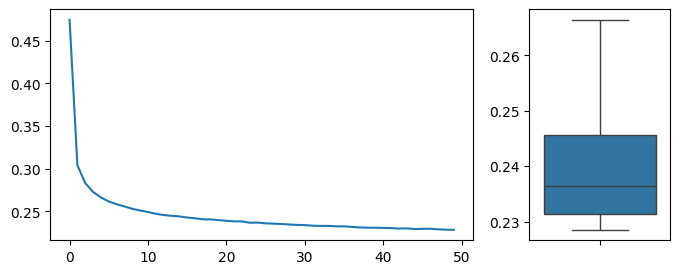

In [30]:
historial = modelo.fit(Xa, Ya, epochs=50)

for metrica, valores in historial.history.items():
    if metrica == "loss":
        figure, axes = pyplot.subplots(1, 2, figsize=(8, 3), width_ratios=[3, 1])
        seaborn.lineplot(x=range(len(valores)), y=valores, ax=axes[0])
        seaborn.boxplot(y=valores, ax=axes[1], showfliers=False)

In [31]:
Xb = X_test.reshape(-1, 28 * 28) / 255

Xb[:10]

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [32]:
y0 = (Y_test == 0).astype(int)
y1 = (Y_test == 1).astype(int)
y2 = (Y_test == 2).astype(int)
y3 = (Y_test == 3).astype(int)
y4 = (Y_test == 4).astype(int)
y5 = (Y_test == 5).astype(int)
y6 = (Y_test == 6).astype(int)
y7 = (Y_test == 7).astype(int)
y8 = (Y_test == 8).astype(int)
y9 = (Y_test == 9).astype(int)

Yb = pandas.DataFrame([y0, y1, y2, y3, y4, y5, y6, y7, y8, y9]).T

Yb

,0,1,2,3,4,5,6,7,8,9
0,0,0,0,0,0,0,0,1,0,0
1,0,0,1,0,0,0,0,0,0,0
2,0,1,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0
4,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
9995,0,0,1,0,0,0,0,0,0,0
9996,0,0,0,1,0,0,0,0,0,0
9997,0,0,0,0,1,0,0,0,0,0
9998,0,0,0,0,0,1,0,0,0,0


In [33]:
modelo.evaluate(Xb, Yb)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 439us/step - accuracy: 0.9140 - loss: 0.3185


[0.2830488681793213, 0.925000011920929]

In [ ]:
# TODO: Guardar la red y probar la predicción de varias imágenes a mano